# Exploratory Data Analysis (EDA)

## Mục tiêu

Notebook này khám phá bộ dữ liệu phân loại rác bằng hình ảnh trước khi huấn luyện mô hình. Các câu hỏi chính:

1. Dữ liệu có bao nhiêu ảnh và bao nhiêu lớp?
2. Số lượng ảnh giữa các lớp có cân bằng hay không?
3. Có ảnh bị hỏng hoặc định dạng không hỗ trợ không?
4. Kích thước và tỷ lệ khung hình của ảnh có đồng nhất không?
5. Một số ảnh đại diện của từng lớp trông như thế nào?

> Nhãn được lấy từ **tên thư mục cha của mỗi ảnh**, đúng với quy ước trong `src/load_data.py`. Notebook không thay đổi dữ liệu gốc.

In [1]:
# Import các thư viện cần thiết.
# Chỉ dùng các thư viện đã khai báo trong requirements.txt để notebook dễ tái lập.
from pathlib import Path
from collections import Counter
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

# Giúp biểu đồ hiển thị rõ ràng hơn trong notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Notebook nằm trong thư mục eda, vì vậy cần đi lên một cấp để tới thư mục gốc dự án.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Thư mục dự án: {PROJECT_DIR}")
print(f"Thư mục dữ liệu: {DATA_DIR}")
print(f"Dữ liệu đã tồn tại: {DATA_DIR.exists()}")

Thư mục dự án: c:\Users\XPS\Desktop\trash-image-classification
Thư mục dữ liệu: c:\Users\XPS\Desktop\trash-image-classification\data
Dữ liệu đã tồn tại: True


## 1. Thu thập danh sách ảnh

Mỗi ảnh hợp lệ được biểu diễn bằng một dòng trong bảng dữ liệu. Cột `path` lưu đường dẫn ảnh, còn cột `label` lưu tên thư mục chứa ảnh. Cách tổ chức này giúp các bước thống kê và vẽ biểu đồ dùng chung một nguồn dữ liệu.

In [2]:
# Quét đệ quy toàn bộ thư mục data và chỉ giữ các phần mở rộng ảnh được hỗ trợ.
records = []

if DATA_DIR.exists():
    for image_path in sorted(DATA_DIR.rglob("*")):
        if image_path.is_file() and image_path.suffix.lower() in SUPPORTED_EXTENSIONS:
            records.append(
                {
                    "path": image_path,
                    "label": image_path.parent.name,
                    "extension": image_path.suffix.lower(),
                }
            )

images_df = pd.DataFrame(records, columns=["path", "label", "extension"])

if images_df.empty:
    print("Chưa tìm thấy ảnh. Hãy chạy src/download_data.py để tải dữ liệu trước.")
else:
    print(f"Tổng số ảnh: {len(images_df):,}")
    print(f"Số lớp: {images_df['label'].nunique()}")
    print("Các lớp:", sorted(images_df["label"].unique()))
    display(images_df.head())

Tổng số ảnh: 12,091
Số lớp: 9
Các lớp: ['Alu', 'Carton', 'Foam_box', 'Milk_box', 'Other', 'PET', 'Paper', 'Paper_cup', 'Plastic_cup']


,path,label,extension
0,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,.jpg
1,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,.jpg
2,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,.jpg
3,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,.jpg
4,c:\Users\XPS\Desktop\trash-image-classificatio...,Alu,.jpg


## 2. Phân bố số lượng ảnh theo lớp

Phân bố lớp cho biết dữ liệu có mất cân bằng hay không. Nếu một lớp có quá ít ảnh so với lớp lớn nhất, mô hình có thể thiên về lớp phổ biến và cần cân nhắc `class weights`, tăng cường dữ liệu hoặc chiến lược lấy mẫu.

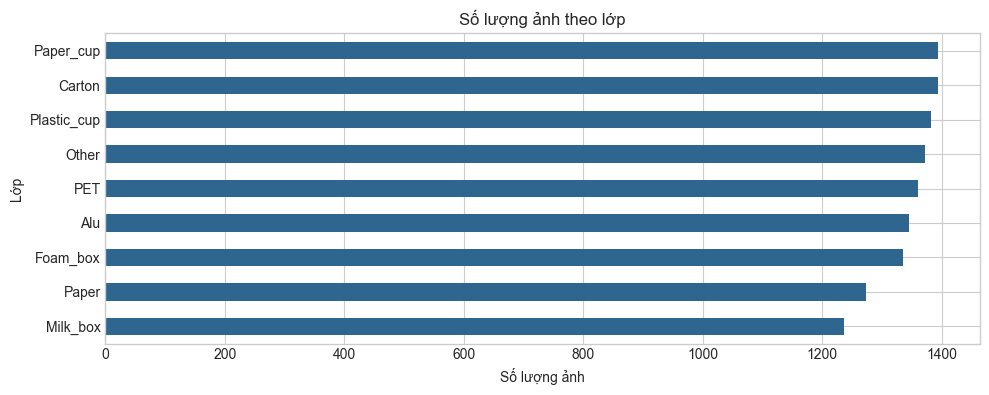

,image_count,percentage
label,,
Carton,1394,11.53
Paper_cup,1394,11.53
Plastic_cup,1382,11.43
Other,1372,11.35
PET,1360,11.25
Alu,1345,11.12
Foam_box,1335,11.04
Paper,1273,10.53
Milk_box,1236,10.22


Tỷ lệ lớp lớn nhất / nhỏ nhất: 1.13 lần


In [3]:
if images_df.empty:
    print("Không thể vẽ phân bố lớp vì chưa có dữ liệu.")
else:
    label_counts = images_df["label"].value_counts().sort_values(ascending=True)
    imbalance_ratio = label_counts.max() / label_counts.min()

    fig, ax = plt.subplots(figsize=(10, max(4, len(label_counts) * 0.45)))
    label_counts.plot.barh(ax=ax, color="#2f6690")
    ax.set_title("Số lượng ảnh theo lớp")
    ax.set_xlabel("Số lượng ảnh")
    ax.set_ylabel("Lớp")
    plt.tight_layout()
    plt.show()

    summary_df = label_counts.rename("image_count").to_frame()
    summary_df["percentage"] = (summary_df["image_count"] / len(images_df) * 100).round(2)
    display(summary_df.sort_values("image_count", ascending=False))
    print(f"Tỷ lệ lớp lớn nhất / nhỏ nhất: {imbalance_ratio:.2f} lần")

## 3. Kiểm tra tính hợp lệ và thuộc tính ảnh

Một file có phần mở rộng ảnh chưa chắc đã đọc được. Ta mở từng file bằng Pillow để phát hiện ảnh hỏng, đồng thời ghi nhận chiều rộng, chiều cao, số kênh màu và định dạng thực tế. Các ảnh lỗi cần được loại bỏ hoặc xử lý trước khi huấn luyện.

In [4]:
# Đọc metadata của từng ảnh; ảnh không đọc được sẽ được ghi riêng để xử lý sau.
metadata = []
corrupt_images = []

for image_path in images_df["path"] if not images_df.empty else []:
    try:
        with Image.open(image_path) as image:
            metadata.append(
                {
                    "path": image_path,
                    "width": image.width,
                    "height": image.height,
                    "channels": len(image.getbands()),
                    "format": image.format,
                    "aspect_ratio": round(image.width / image.height, 3),
                }
            )
    except (UnidentifiedImageError, OSError):
        corrupt_images.append(image_path)

metadata_df = pd.DataFrame(metadata)

print(f"Ảnh đọc được: {len(metadata_df):,}")
print(f"Ảnh lỗi: {len(corrupt_images):,}")
if corrupt_images:
    print("Một số file lỗi:")
    for path in corrupt_images[:10]:
        print(f"- {path}")

if not metadata_df.empty:
    display(metadata_df[["width", "height", "channels", "format", "aspect_ratio"]].describe(include="all"))

Ảnh đọc được: 12,091
Ảnh lỗi: 0


,width,height,channels,format,aspect_ratio
count,12091.000000,12091.000000,12091.000000,12091,12091.000000
unique,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,JPEG,NaN
freq,NaN,NaN,NaN,11492,NaN
mean,697.256141,627.051278,3.000000,NaN,1.146382
std,722.840650,673.249984,0.279726,NaN,0.310658
min,50.000000,50.000000,1.000000,NaN,0.128000
25%,246.000000,225.000000,3.000000,NaN,1.000000
50%,479.000000,384.000000,3.000000,NaN,1.000000
75%,800.000000,720.000000,3.000000,NaN,1.333000


## 4. Phân tích kích thước và định dạng

Kích thước ảnh không đồng nhất thường không phải lỗi vì pipeline có thể resize ảnh. Tuy nhiên, ảnh quá nhỏ có thể mất thông tin; tỷ lệ khung hình quá khác biệt có thể gây méo khi resize. Các biểu đồ dưới đây giúp chọn kích thước đầu vào và phép biến đổi phù hợp.

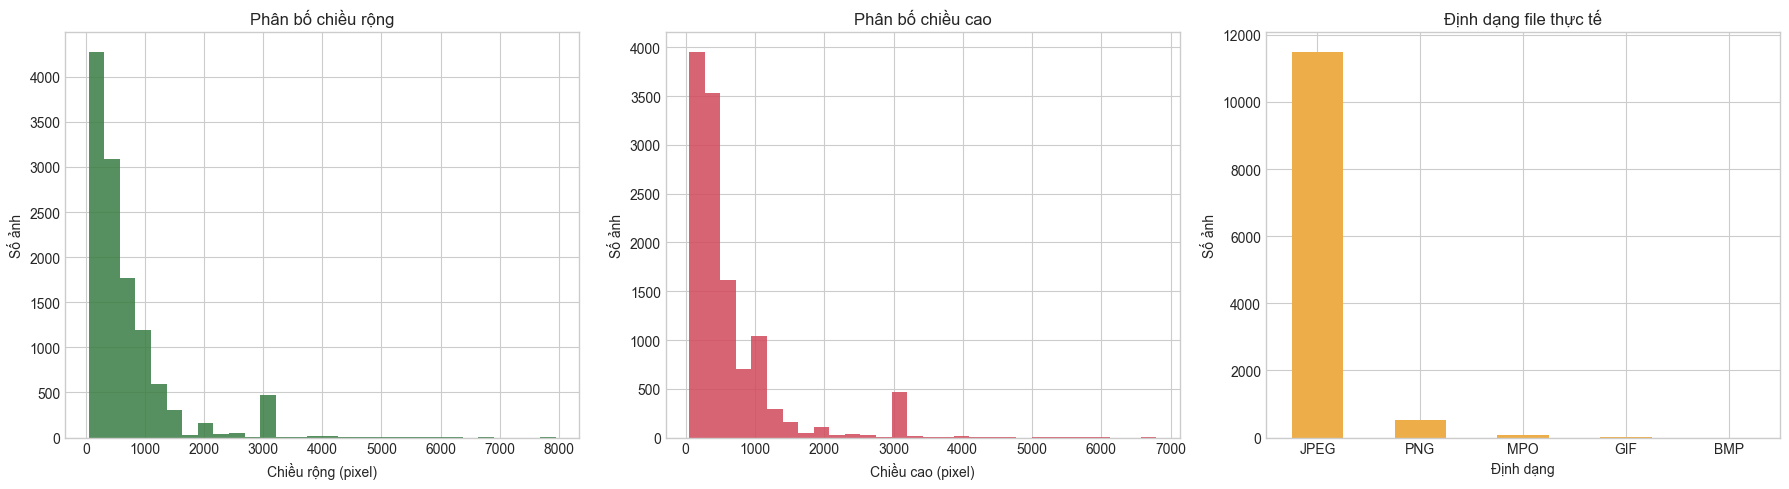

Tỷ lệ khung hình nhỏ nhất: 0.128
Tỷ lệ khung hình lớn nhất: 6.4


In [5]:
if metadata_df.empty:
    print("Chưa có metadata để phân tích.")
else:
    figure, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(metadata_df["width"], bins=30, color="#3a7d44", alpha=0.85)
    axes[0].set_title("Phân bố chiều rộng")
    axes[0].set_xlabel("Chiều rộng (pixel)")
    axes[0].set_ylabel("Số ảnh")

    axes[1].hist(metadata_df["height"], bins=30, color="#d1495b", alpha=0.85)
    axes[1].set_title("Phân bố chiều cao")
    axes[1].set_xlabel("Chiều cao (pixel)")
    axes[1].set_ylabel("Số ảnh")

    metadata_df["format"].value_counts().plot.bar(ax=axes[2], color="#edae49")
    axes[2].set_title("Định dạng file thực tế")
    axes[2].set_xlabel("Định dạng")
    axes[2].set_ylabel("Số ảnh")
    axes[2].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

    print("Tỷ lệ khung hình nhỏ nhất:", metadata_df["aspect_ratio"].min())
    print("Tỷ lệ khung hình lớn nhất:", metadata_df["aspect_ratio"].max())

## 5. Trực quan hóa ảnh đại diện

Xem ảnh thật giúp phát hiện những vấn đề mà thống kê không thể hiện, chẳng hạn nền ảnh không nhất quán, nhiều vật thể trong một ảnh, ảnh bị xoay hoặc nhãn không phù hợp. Mỗi lớp được lấy tối đa một số ảnh ngẫu nhiên để dễ so sánh.

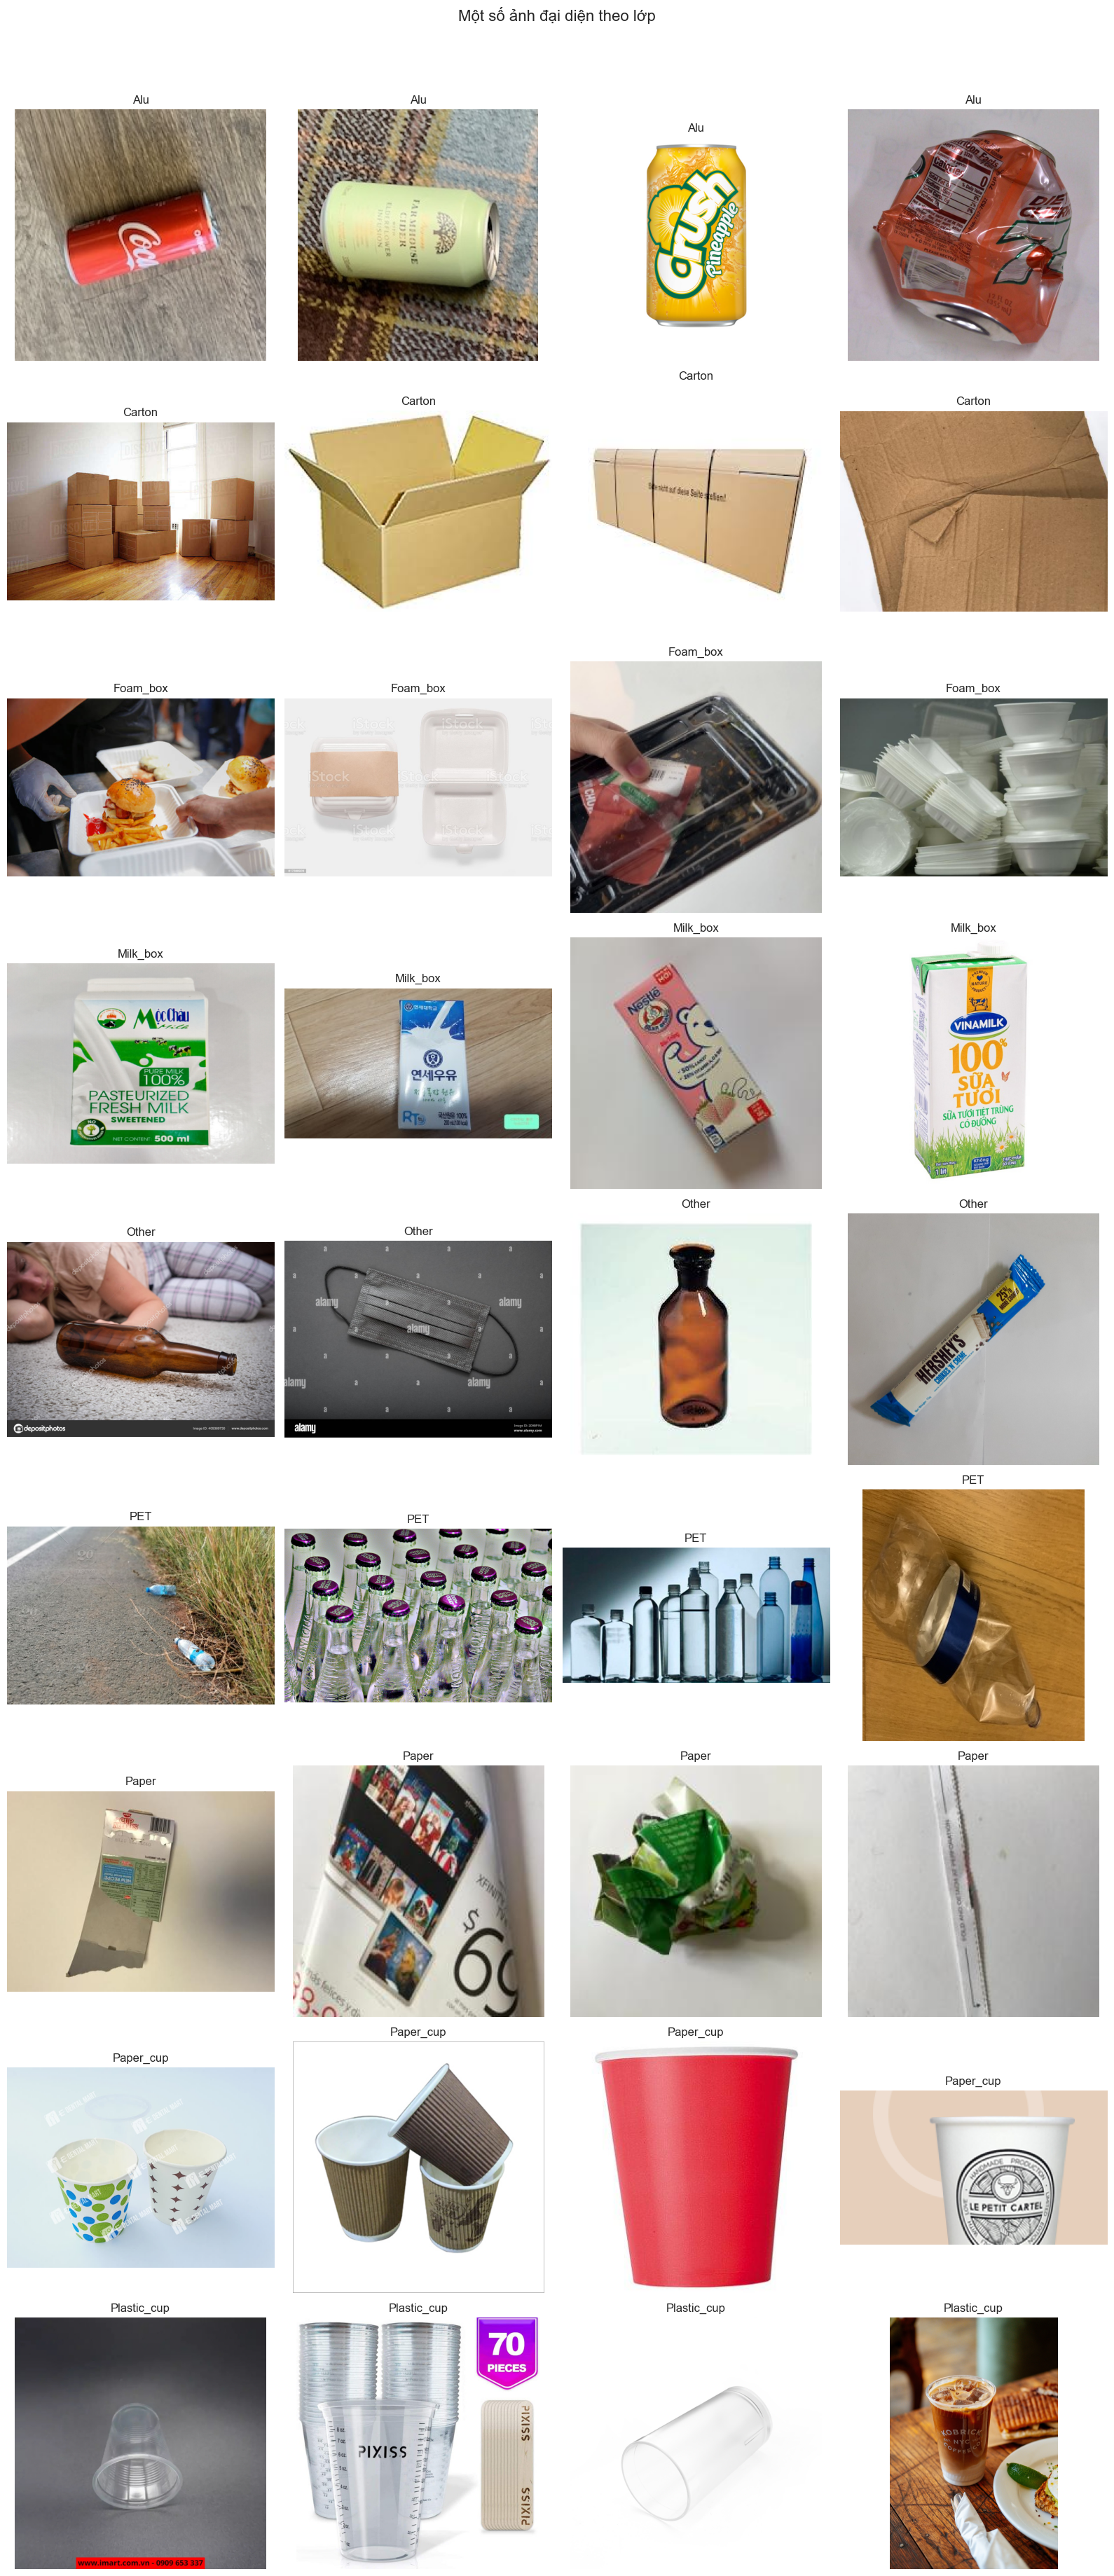

In [6]:
if images_df.empty:
    print("Chưa có ảnh để trực quan hóa.")
else:
    labels = sorted(images_df["label"].unique())
    columns = 4
    rows = len(labels)
    figure, axes = plt.subplots(rows, columns, figsize=(16, max(4, rows * 4)))
    axes = np.atleast_2d(axes)

    for row_index, label in enumerate(labels):
        examples = images_df[images_df["label"] == label].sample(
            n=min(columns, (images_df["label"] == label).sum()),
            random_state=RANDOM_SEED,
        )

        # Ẩn các ô thừa để bố cục không gây nhầm rằng đó là ảnh dữ liệu.
        for axis in axes[row_index]:
            axis.axis("off")

        for column_index, (_, record) in enumerate(examples.iterrows()):
            try:
                with Image.open(record["path"]) as image:
                    axes[row_index, column_index].imshow(image.convert("RGB"))
                axes[row_index, column_index].set_title(label)
                axes[row_index, column_index].axis("off")
            except (UnidentifiedImageError, OSError):
                axes[row_index, column_index].set_title("Ảnh lỗi")

    plt.suptitle("Một số ảnh đại diện theo lớp", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

## 6. Kết luận và việc cần làm trước khi huấn luyện

Dựa trên kết quả chạy notebook, cần ghi lại các điểm sau:

- **Quy mô dữ liệu:** tổng số ảnh và số lớp.
- **Mất cân bằng lớp:** so sánh lớp nhiều ảnh nhất với lớp ít ảnh nhất.
- **Chất lượng file:** kiểm tra và loại bỏ hoặc thay thế ảnh lỗi.
- **Kích thước đầu vào:** chọn kích thước resize dựa trên phân bố chiều rộng, chiều cao và tỷ lệ khung hình.
- **Đa dạng hình ảnh:** xem ảnh mẫu để phát hiện nền, góc chụp hoặc vật thể gây khó cho mô hình.
